# Master Project – Preliminary Analysis of Directed Networks

---
**Author:** Thomas Rey  
**Supervisor:** Matúš Medo    
**Date of creation:** 26 September 2025  

_**Objective**: Set up the basis for the Master work by analysing random directed networks: implementation and comparison of three node metrics: in-degree, PageRank and Zermelo's strength on different types of networks (simple random / based on Bradley-Terry / biased participations)_

**Estimated runtime**: about 6-8 minutes on a standard laptop (with the .pkl files)

**Unusual library used:** tqdm / os / pickle

---

$\boxed{\textbf{Important note: For the full analysis, discussions, and theoretical background, all information is available in the project's report (pdf file).}}$

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import pearsonr, spearmanr #libraries for calculating correlations
from tqdm import tqdm
import os 
import pickle

## 1. Generation of Synthetic Networks

### 1.1. Simple Random Networks


In [3]:
def generate_random_network(N,E, draw=False):
    """
    Generates a random directed network with N nodes and E edges, 
    where the links between nodes and their directions are randomly assigned.

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        draw (bool): If True, the network is drawn (default: False).

    Returns:
        G (DiGraph (from NetworkX)) : A directed graph corresponding to the generated random network.
        
    """
    #check if the number of edges asked is possible 
    if E>N*(N-1): 
        raise ValueError(f"The maximum number of directed edges with {N} nodes is {N*(N-1)}.")

    #creation of the graph with N nodes
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    #creation of the edges by randomly choosing E edges from the list of all possibles edges (no self-loop)
    all_edges = [(i,j) for i in range(N) for j in range(N) if i!=j]
    
    chosen_indices = np.random.choice(len(all_edges), size=E, replace=False) #indices of the chosen edges, without replacement
    chosen_edges = [all_edges[i] for i in chosen_indices]
    G.add_edges_from(chosen_edges)

    #if asked, graph is drawn
    if draw:
        nx.draw_spring(G, with_labels=True)
        plt.show()

    return G

# example
# generate_random_network(20, 12, draw=True)
# nx.gnm_random_graph(5, 20, directed=True)

_Note: `nx.gnm_random_graph(N, E, directed=True)` provides exactly the same result. For the following, this predefined function will be used._

### 1.2. Bradley-Terry Networks

In [4]:
def generate_BT_network(N, E):
    """
    Generates a directed random network with N nodes and E edges, 
    where the links between nodes and their directions are assigned based on Zermelo's model of paired comparisons.
    Note that the number of edges created in the network may be lower than E if some edges are duplicated.

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.

    Returns:
        G (diGraph (from NetworkX)) : A directed graph corresponding to the generated random network.
        true_node_strengths (dict): A dictionary with node indices as keys and their true strengths as values.

        
    """


    #check if the number of edges asked is possible 
    if E>N*(N-1): 
        raise ValueError(f"The maximum number of directed edges with {N} nodes is {N*(N-1)}.")
    
    #creation of the true node strengths
    true_node_strengths = {i: np.random.rand() for i in range(N)}

    #creation of the graph with N nodes
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

 
    for _ in range(E):
        i, j = np.random.choice(range(N), size=2, replace=False)
        p_ij = true_node_strengths[i]/(true_node_strengths[i]+true_node_strengths[j]) 


        if np.random.rand() < p_ij: #creation of a random number btw 0 and 1 to see if i or j wins
            G.add_edge(j,i)
      
        else:
            G.add_edge(i,j)
       
            
    return G, true_node_strengths

#example
# G, true_strengths = generate_BT_network(50,500)
# print(true_strengths)
# print(f"Number of edges (knowing that 500 edges were requested):", len(G.edges()))
# nx.draw_spring(G, with_labels=True)

### 1.3. Biased Networks

Biased networks are constructed as the BT network, but the difference is that the pairs of nodes are not chosen randomly, but according to a certain probability. 

In networks, nodes are labelled from $0$ to $N-1$, so the probability of selecting a node $i$ is initally $1/\sqrt{i+1}$ (shift for avoiding division by 0). To ensure that the sum of probabilities is 1, we have to normalize  each terme by the total sum over all nodes:

\begin{equation*} P(i)=\frac{1/\sqrt{i+1}}{\sum_{j=0}^{N-1} 1/\sqrt{j+1}} \end{equation*}

In [5]:
def generate_biased_network(N,E):
    """
    Generates a directed random network with N nodes and E edges, where pair of nodes are selected at random, 
    where lower IDs are more likely to be selected. 
    The directions of the edges are determined using Zermelo's model and probability.
    Note that the number of edges created in the network may be lower than E if some edges are duplicated.

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.

    Returns:
        G (diGraph (from NetworkX)) : A directed graph corresponding to the generated random network.
        true_node_strengths (dict): A dictionary with node indices as keys and their true strengths as values.

    """

    #check if the number of edges asked is possible 
    if E>N*(N-1): 
        raise ValueError(f"The maximum number of directed edges with {N} nodes is {N*(N-1)}.")
    

    #creation of the true node strengths
    true_node_strengths = {i: np.random.rand() for i in range(N)}

    #creation of the graph with N nodes
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    # create a list containing probabilities for a node to be chosen: 1/sqrt(i+1)/sum of probabilities
    probabilities = [(1/np.sqrt(i+1))/np.sum([1/np.sqrt(j+1) for j in range(N)]) for i in range(N)]

    #choosing pair of nodes according to the probabilities
    for _ in range(E):
        i, j = np.random.choice(range(N), size=2, replace=False, p=probabilities)
        p_ij = true_node_strengths[i]/(true_node_strengths[i]+true_node_strengths[j]) 


        if np.random.rand() < p_ij: #creation of a random number btw 0 and 1 to see if i or j wins
            G.add_edge(j,i)
      
        else:
            G.add_edge(i,j)
       
            
    return G, true_node_strengths
    

# example
# G, true_strengths = generate_biased_network(50,1000)
# print(true_strengths)
# print(f"Number of edges (knowing that 1000 edges were requested):", len(G.edges()))
# nx.draw_spring(G, with_labels=True)

## 2. Nodes Metrics: In-Degree / PageRank Algorithm / Zermelo's Strength

### 2.1. In-Degree

It counts the number of incoming edges for each node of the network. In our context, it represents a "win". For node $i$, it can be defined as follows:
\begin{equation*} s^{in}_i=\sum_j e_{ji}\end{equation*}
with $e_{ji}=1$ if there is a directed edge from $j$ to $i$, and $e_{ji}=0$ otherwise. 


In [6]:
def compute_in_degree(G):
    """
    Computes the in-degrees of all nodes of the directed graph G

    Args:
        G (DiGraph (from NetworkX)) : A directed graph.

    Returns:
        in_degrees (dict): A dictionary with node indices as keys and their in-degrees as values.

    """
    in_degrees = dict(G.in_degree())

    return in_degrees

#example
#G = generate_random_network(5, 8, draw=True)
#print(compute_in_degree(G))

### 2.2. PageRank

It is defined recursively on the scores of the nodes pointing to it. For node $i$, it is expressed as:


\begin{equation*} P_i = (1-\alpha) \sum_{j: s^{out}_j > 0} P_j \frac{e_{ji}}{s^{out}_j}  + \frac{\alpha}{N} + \frac{1-\alpha}{N} \sum_{j: s^{out}_j = 0} P_j  \end{equation*}

where: 
- $s_j^{out}=\sum_k e_{jk} $ is the out-degree of node $j$
- $\alpha \in [0,1]$ is the _algorithm parameter_, also called _teleportation probability_ (typically, $\alpha = 0.15$)
- the last term accounts for the nodes without outgoing edges (called _dangling nodes_)
---

To get familiar with _NetworkX_, implementation of the PageRank algorithm by hand is made, without using the predefined function. Then, comparison between this implementation and `nx.pagerank(G,1-alpha, max_iter, tol)`.

To apply the iterative equation, initial values $P_i^{(0)}$ to the nodes need to be assigned. Since the sum over all N has to be equal to 1 at each iteration $t$ (i.e. $\sum_i P_i^{(t)} =1$), a uniform distribution is assumed for simplicity, i.e.

\begin{equation*} P_i^{(0)} = 1/N, \hspace{5mm} \forall i. \end{equation*}



In [7]:
def compute_homemade_pagerank(G, alpha=0.15, max_iter=500, tol=1.0e-6, iterations_needed=False):
    """
    Computes the PageRank of all nodes of the directed graph using the recursive formula

    Args:
        G (DiGraph (from NetworkX)): A directed graph.
        alpha (float): Teleportation probability (default: 0.15), has to be in [0,1]
        max_iter (int): Maximum number of iterations to perform (default: 500).
        tol (float): Tolerance for convergence (default:1.0e-6).
        iterations_needed (bool): If True, the number of iterations is printed when convergence is reached (default: False).
        
    
    Returns:
        P_0 (dict): A dictionary with node indices as keys and their PageRank values (after convergence) as values.
        converged (bool): True if convergence was reached, False otherwise.


    """
    #check if the input value for alpha is in the good range
    if alpha>1 or alpha<0: 
        raise ValueError("The teleportation probability alpha has to be between 0 and 1.")
    
    #initial values P_i^{0} via uniform distribution
    N=len(G)
    P_0=dict.fromkeys(range(N), 1/N)

    #apply algorithm based on formula -----------
    for _ in range(max_iter): 

        P_next = {} #empty dictionary for storing the new values
        
        #compute the new pagerank score for each node
        for i in G.nodes:
            dangling_sum=0 #contribution from nodes with no outgoing edges
            linked_sum=0 #contribution from nodes pointing to i

            for j in G.nodes:
                if j!=i:
                    s_j_out= G.out_degree(j) #out-degree of node j

                    # dangling node
                    if s_j_out==0:
                        dangling_sum+=P_0[j]

                    # linked node
                    else:
                        if G.has_edge(j,i): #meaning that e_ji=1
                            linked_sum+=P_0[j]/s_j_out

            #new pagerank score calculated from the two sums
            P_next[i]=(1-alpha)*linked_sum + alpha/N + (1-alpha)*dangling_sum/N
        

        #checking the convergence of the algorithm -----------
        difference = sum(abs(P_next[i]-P_0[i]) for i in G.nodes) #sum of the absolute differences
        P_0=P_next #update
        
        if difference < N * tol: #convergence criterion
            if iterations_needed:
                print(f"Convergence has been reached after {_+1} iterations.")
            return P_0, True
    
    else:
        if iterations_needed:
            print(f"WARNING: Convergence has not been reached after {max_iter} iterations!")
        return P_0, False

#### Comparison of the scores

In [8]:
def compare_pagerank_algorithms(N, E, alpha=0.15, max_iter=500, tol=1.0e-6):

    """
    Compares the PageRank values obtained from the home-made algorithm and the built-in NetworkX
    
    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        alpha (float): Teleportation probability (default: 0.15), has to be in [0,1]
        max_iter (int): Maximum number of iterations to perform (default: 500).
        tol (float): Tolerance for convergence (default:1.0e-6).
    
    Returns:
        None, but prints the results of the comparison.
    """
    
    G=nx.gnm_random_graph(N, E, directed=True)

    built_in_pr = nx.pagerank(G, alpha=1-alpha, max_iter=max_iter, tol=tol)
    home_made_pr, convergence = compute_homemade_pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol)

    differences = [abs(home_made_pr[i]-built_in_pr[i]) for i in G.nodes]
    mean_difference = np.mean(differences)
    standard_difference = np.std(differences)

    print(f"---Results for N={N} and E={E}---")

    if not convergence:
        print("WARNING: Home-made PageRank did not converge!")
    else:
        print("Home-made PageRank converged!")
        print(f"Mean absolute difference between home-made and built-in: {mean_difference:.5f} ± {standard_difference/np.sqrt(len(G)):.5f}")


    print(f"Example score for node 0: \n home-made = {home_made_pr[0]:.5f} \n built-in = {built_in_pr[0]:.5f} \n")

In [9]:
compare_pagerank_algorithms(50, 1000) #strongly connected network
compare_pagerank_algorithms(50, 50)  #sparse network

---Results for N=50 and E=1000---
Home-made PageRank converged!
Mean absolute difference between home-made and built-in: 0.00000 ± 0.00000
Example score for node 0: 
 home-made = 0.02013 
 built-in = 0.02013 

---Results for N=50 and E=50---
Home-made PageRank converged!
Mean absolute difference between home-made and built-in: 0.00076 ± 0.00007
Example score for node 0: 
 home-made = 0.00856 
 built-in = 0.00900 



#### Comparison of runtimes

In [10]:
def measure_pagerank_runtime(function, G, run_number=50):
    """
    Computes the average time needed to run one of the algorithm for PageRank over a given number of iterations

    Args:
        function (callable): has to be either "nx.pagerank" or "compute_homemade_pagerank" 
        G : Random directed graph
        run_number (int): the number of times the runtime is calculated (default:20)

    Returns:
        The mean runtime of the function and its error

    """
    if function!=nx.pagerank and function!=compute_homemade_pagerank:
        raise ValueError(f"WARNING: The function called has to be either 'nx.pagerank' or 'compute_homemade_pagerank' ")


    runtimes=[] #list containing the runtime of the function

    for _ in range(run_number):
        start_time=time.time()
        function(G)
        end_time=time.time()
        runtimes.append(end_time-start_time)

    return np.mean(runtimes), np.std(runtimes)/np.sqrt(run_number)

In [11]:
G = nx.gnm_random_graph(50, 1000, directed=True)
built_in_runtime, built_in_error = measure_pagerank_runtime(nx.pagerank, G, 100)
home_made_runtime, home_made_error = measure_pagerank_runtime(compute_homemade_pagerank, G, 100)

print(f"Built-in PageRank: {built_in_runtime:.5e}s ± {built_in_error:5f}s") 
print(f"Home-made PageRank: {home_made_runtime:5e}s ± {home_made_error:5f}s")
print("------------")
print(f"Built-in algorithm is about {home_made_runtime/built_in_runtime:.2f} ± {home_made_runtime/built_in_runtime*np.sqrt((home_made_error/home_made_runtime)**2+(built_in_error/built_in_runtime)**2):.2f} times faster!")

Built-in PageRank: 7.30052e-04s ± 0.000042s
Home-made PageRank: 4.088147e-03s ± 0.000007s
------------
Built-in algorithm is about 5.60 ± 0.32 times faster!


---
**WARNING**: As the function `nx.pagerank` has an argument $\alpha$ that corresponds to our parameter minus 1, `compute_pagerank` function is a new function taking our parameter alpha and not the one defined directly in the built-in function:


In [12]:
def compute_pagerank(G, alpha, max_iter=5000, tol=1e-6):
    return nx.pagerank(G, alpha=1-alpha, max_iter=max_iter, tol=tol)

---

_Note: For the next parts of the project, the predefined function will be used for efficiency._

### 2.3. Zermelo's node strength

Each player $i$ is assigned a parameter $\pi_i>0$, corresponding to its strength. The probability $p_{ij}$ that player $i$ beats player $j$ is then given by the Bradley-Terry model with
\begin{equation*} p_{ij}=\frac{\pi_i}{\pi_i+\pi_j}. \end{equation*}

The Zermelo's node strengths $\pi_i$ are obtained through an iterative algorithm, called **Zermelo's algorithm**:

\begin{equation*} \pi_i' = \frac{\sum_j  e_{ji}}{\sum_j (e_{ij} + e_{ji})/(\pi_i + \pi_j)}  \end{equation*}


There also exists a faster version, which converges to the same solution:

\begin{equation*} \pi_i' = \frac{\sum_j e_{ji}\pi_j/(\pi_i + \pi_j)}{\sum_j e_{ij}/(\pi_i + \pi_j)} \end{equation*}

**Note**: The node strengths $\pi_i$ are updated using an $\underline{\text{asynchronous update procedure}}$ (more efficient than a synchronous update). The initial values of $\pi_i$ were chosen randomly such that the scores $s_i$ are drawn from a logistic distribution: 
\begin{equation*} f(s) = \frac{1}{(e^s+1)(e^{-s}+1)} \end{equation*}

with the relation $\pi_i = e^{s_i}$. 

In [13]:
def compute_zermelo_strength(G, max_iter=5000, tol=1.0e-6, method="fast", show_convergence=False, keep_differences=False):

    """
    Computes the Zermelo's node strength of all nodes of the directed graph using the recursive formula asynchronously (faster algorithm)

    Args:
        G (DiGraph (from NetworkX)): A directed graph.
        max_iter (int): Maximum number of iterations to perform (default: 5000).
        tol (float): Tolerance for convergence (default:1.0e-6).
        method (str): Choose the method to compute Zermelo's node strength, "fast" (default) or "slow".
        show_convergence (bool): If True, the number of iterations is returned when convergence is reached (default: False).
        
    
    Returns:
        pi_0 (dict): A dictionary with node indices as keys and their Zermelo's node strengths (after convergence) as values.
        differences (list of float): List of differences at each iteration (if keep_differences is True).
        iterations (int): Number of iterations needed to reach convergence (if show_convergence is True).


    """
    epsilon=1e-12 #for avoiding division by zero

    if method not in ["fast", "slow"]:
        raise ValueError("The method has to be either 'fast' or 'slow'.")
    
    N=len(G)
    nodes=list(G.nodes)

    #define the initial values of pi=e^s with s from a logistic distribution 
    s=np.random.logistic(size=N)
    pi_0={nodes[i]: np.exp(s[i]) for i in range(N)}

    differences=[]

    # iterate over all nodes and update pi_i
    for iteration in range(max_iter):
        difference=0
        for i in nodes:

            #calculating with fast algorithm
            if method == "fast":
                numerator = sum(pi_0[j]/(pi_0[i]+pi_0[j]+epsilon) for j in nodes if G.has_edge(j,i))
                denominator = sum(1/(pi_0[i]+pi_0[j]+epsilon) for j in nodes if G.has_edge(i,j))
                
            #calculating with slow algorithm
            elif method == "slow":
                numerator = sum(1 for j in nodes if G.has_edge(j,i))
                denominator = sum((int(G.has_edge(i,j))+int(G.has_edge(j,i)))/(pi_0[i]+pi_0[j]) for j in nodes)


            if denominator >0:
                new_pi_i = numerator/denominator
                difference += abs(new_pi_i-pi_0[i])
                pi_0[i] = new_pi_i #asynchronous update
        
        if keep_differences:
            differences.append(difference)

        #check the convergence after completing one change for each node
        if difference < N * tol:

            values=np.maximum(list(pi_0.values()), epsilon)

            pi_product=np.prod(values)
            pi_0={i: pi_0[i]/(pi_product**(1/N)) for i in nodes} #normalization so that the product of all pi_i is 1

            if show_convergence and keep_differences:
                return pi_0, differences, iteration+1
            
            elif show_convergence:
                return pi_0, iteration+1
            
            elif keep_differences:
                return pi_0, differences
            
            else:
                return pi_0


    raise ValueError(f"WARNING: Convergence (with {method} version) has not been reached after {max_iter} iterations!")


**Note**: As the strengths are defined up to a multiplicative constant, we normalize them after convergence such that $\prod_i \pi_i = 1$. When normalizing the values, there is a risk to divide by 0 (if one of the strength is zero)! To avoid this problem, we consider the values to be the maximum between $\pi_i$ and a very small value $\epsilon$.

**Note**: The algorithm created to compute $\pi_i$ for each node $i$ of the network works only if the graph is **strongly connected**. If it is not the case, some nodes have very few or no in/out-edges, which causes certain $\pi_i$ to become zero. For this reason, the tests performed will be done on strongly connected graphs (high $E$ compared to $N$, i.e. high ratio $E/N$).


#### Comparing both algorithms (fast and slow)

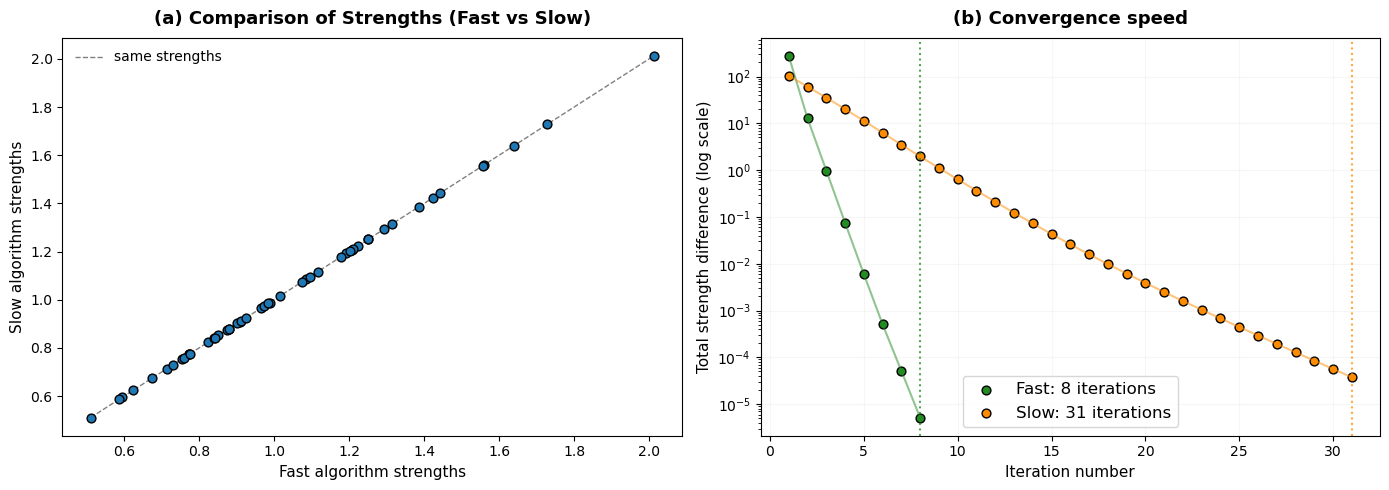

In [14]:
#creation of a random directed network, highly connected
G=nx.gnm_random_graph(50, 1000, directed=True)

#calculation of Zermelo's strengths with both algorithms
zermelo_fast, differences_fast,iter_fast = compute_zermelo_strength(G, method="fast", show_convergence=True, keep_differences=True)
zermelo_slow, differences_slow, iter_slow = compute_zermelo_strength(G, method="slow", show_convergence=True, keep_differences=True)

strengths_fast=list(zermelo_fast.values())
strengths_slow=list(zermelo_slow.values())

#find min and max strengths for plotting the diagonal line
minimum_strength=min(min(strengths_fast), min(strengths_slow))
maximum_strength=max(max(strengths_fast), max(strengths_slow))

plt.figure(figsize=(14,5))

#plot of the comparison of the strengths between both algorithms
plt.subplot(1,2,1)
plt.plot([minimum_strength, maximum_strength], [minimum_strength, maximum_strength], color="gray", 
         linestyle="--", label="same strengths", zorder=1, linewidth=1,) #diagonal line
plt.scatter(strengths_fast, strengths_slow, marker="o", zorder=2, edgecolor="black", s=40) 
plt.title("(a) Comparison of Strengths (Fast vs Slow)", fontsize=13, weight="bold", pad=10)
plt.xlabel("Fast algorithm strengths", fontsize=11)
plt.ylabel("Slow algorithm strengths", fontsize=11)
plt.legend(frameon=False, fontsize=10)


# plot of the speed of convergence for both algorithms
plt.subplot(1,2,2)

plt.scatter(range(1, iter_fast+1), differences_fast, label=f"Fast: {iter_fast} iterations", 
            color="forestgreen", edgecolor="black", s=40)
plt.plot(range(1, iter_fast+1), differences_fast, color="forestgreen", alpha=0.5)

plt.scatter(range(1, iter_slow+1), differences_slow, label=f"Slow: {iter_slow} iterations", 
            color="darkorange", edgecolor="black", s=40)
plt.plot(range(1, iter_slow+1), differences_slow, color="darkorange", alpha=0.5)

plt.yscale("log")
plt.axvline(iter_fast, linestyle=":", color="forestgreen", alpha=0.75)
plt.axvline(iter_slow, linestyle=":", color="darkorange", alpha=0.75)

plt.title("(b) Convergence speed", fontsize=13, weight="bold", pad=10)
plt.xlabel("Iteration number", fontsize=11)
plt.ylabel("Total strength difference (log scale)", fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.1)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [15]:
strengths_differences=[np.abs(strengths_fast[i]-strengths_slow[i]) for i in range(len(strengths_fast))]
mean_difference = np.mean(strengths_differences)
std_difference = np.std(strengths_differences)

print(f"Mean absolute difference for strengths between both algorithms: {mean_difference:.2e} ± {std_difference/np.sqrt(len(strengths_differences)):.2e}")

Mean absolute difference for strengths between both algorithms: 7.01e-07 ± 2.68e-07


## 3. Inter-Metric Correlations (with Random Networks)

In [16]:
def compare_metrics_random_networks(N, E, graph_number=100, max_iter=500, tol=1.0e-6, alphas=[0.15]):
    """
    Compares in-degree, Zermelo strength, and PageRank correlations on the same set of random graphs

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        graph_number (int): Number of random graphs to generate (default: 100).
        max_iter (int): Maximum number of iterations for Zermelo and PageRank  (default: 5000).
        tol (float): Tolerance for convergence (default: 1.0e-6).


    Returns:
        3 dictionaries for in-degree vs Zermelo, in-degree vs PageRank (for all alphas), Zermelo vs PageRank (for all alphas)
    """

    pearson_in_degree_zermelo_values = []
    spearman_in_degree_zermelo_values = []

    pearson_zermelo_pr_values = {alpha: [] for alpha in alphas}
    spearman_zermelo_pr_values = {alpha: [] for alpha in alphas}

    pearson_in_degree_pr_values = {alpha: [] for alpha in alphas}
    spearman_in_degree_pr_values = {alpha: [] for alpha in alphas}


    
    for _ in tqdm(range(graph_number), desc="Processing graphs"):

        G = nx.gnm_random_graph(N, E, directed=True)
        nodes=list(G.nodes())

        # Compute metrics which don"t depend on alpha
        in_degrees = [compute_in_degree(G)[node] for node in nodes]
        zermelo_strengths = [compute_zermelo_strength(G, method="fast")[node] for node in nodes]

        pearson_indegree_zermelo = pearsonr(in_degrees, zermelo_strengths)[0]
        spearman_indegree_zermelo = spearmanr(in_degrees, zermelo_strengths)[0]

        pearson_in_degree_zermelo_values.append(pearson_indegree_zermelo)
        spearman_in_degree_zermelo_values.append(spearman_indegree_zermelo)

        #compute PageRank
        for alpha in alphas:
            
            pageranks = [compute_pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol)[node] for node in nodes]

            pearson_zermelo_pagerank = pearsonr(zermelo_strengths, pageranks)[0]
            spearman_zermelo_pagerank = spearmanr(zermelo_strengths, pageranks)[0]

            pearson_zermelo_pr_values[alpha].append(pearson_zermelo_pagerank)
            spearman_zermelo_pr_values[alpha].append(spearman_zermelo_pagerank)

            pearson_indegree_pagerank = pearsonr(in_degrees, pageranks)[0]
            spearman_indegree_pagerank = spearmanr(in_degrees, pageranks)[0]

            pearson_in_degree_pr_values[alpha].append(pearson_indegree_pagerank)
            spearman_in_degree_pr_values[alpha].append(spearman_indegree_pagerank)
            
        
    results = {
    "in_degree_zermelo": {
        "pearson": (np.mean(pearson_in_degree_zermelo_values), np.std(pearson_in_degree_zermelo_values)/np.sqrt(graph_number)),
        "spearman": (np.mean(spearman_in_degree_zermelo_values), np.std(spearman_in_degree_zermelo_values)/np.sqrt(graph_number))
    },
    "in_degree_pagerank": {
        alpha: {
            "pearson": (np.mean(pearson_in_degree_pr_values[alpha]), np.std(pearson_in_degree_pr_values[alpha])/np.sqrt(graph_number)),
            "spearman": (np.mean(spearman_in_degree_pr_values[alpha]), np.std(spearman_in_degree_pr_values[alpha])/np.sqrt(graph_number))
                } for alpha in alphas
                            },
    "zermelo_pagerank": {
        alpha: {
            "pearson": (np.mean(pearson_zermelo_pr_values[alpha]), np.std(pearson_zermelo_pr_values[alpha])/np.sqrt(graph_number)),
            "spearman": (np.mean(spearman_zermelo_pr_values[alpha]), np.std(spearman_zermelo_pr_values[alpha])/np.sqrt(graph_number))
                } for alpha in alphas
                        }
    }

    return results

In [17]:
alphas = np.concatenate((np.arange(0.05, 1, 0.1), [0.99, 0.999]))
random_networks_metrics=compare_metrics_random_networks(50, 1000, graph_number=200, alphas = alphas)

Processing graphs: 100%|██████████| 200/200 [02:37<00:00,  1.27it/s]


In [18]:
print("Results for correlation between in-degree and Zermelo's strength:")
print("------------------------------------")
print("Pearson:", round(random_networks_metrics["in_degree_zermelo"]["pearson"][0],3), "±", round(random_networks_metrics["in_degree_zermelo"]["pearson"][1],3))
print("Spearman:", round(random_networks_metrics["in_degree_zermelo"]["spearman"][0],3), "±", round(random_networks_metrics["in_degree_zermelo"]["spearman"][1],3))

Results for correlation between in-degree and Zermelo's strength:
------------------------------------
Pearson: 0.666 ± 0.006
Spearman: 0.679 ± 0.006


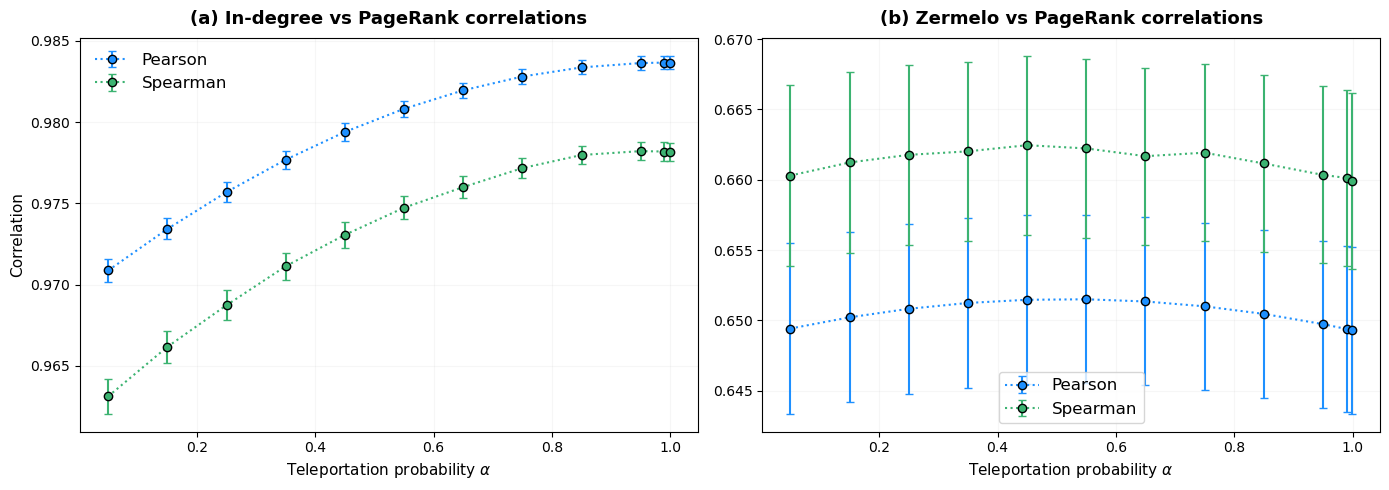

In [19]:
mean_pearson_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["pearson"][0] for alpha in alphas]
se_pearson_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["pearson"][1] for alpha in alphas]
mean_spearman_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["spearman"][0] for alpha in alphas]
se_spearman_ip = [random_networks_metrics["in_degree_pagerank"][alpha]["spearman"][1] for alpha in alphas]

mean_pearson_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["pearson"][0] for alpha in alphas]
se_pearson_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["pearson"][1] for alpha in alphas]
mean_spearman_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["spearman"][0] for alpha in alphas]
se_spearman_zp = [random_networks_metrics["zermelo_pagerank"][alpha]["spearman"][1] for alpha in alphas]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.errorbar(alphas, mean_pearson_ip, yerr=se_pearson_ip, label="Pearson", marker="o", linestyle=":", capsize=3, 
             markeredgecolor="black", color="dodgerblue")
plt.errorbar(alphas, mean_spearman_ip, yerr=se_spearman_ip, label="Spearman", marker="o", linestyle=":", capsize=3, 
             markeredgecolor="black", color="mediumseagreen")
plt.title("(a) In-degree vs PageRank correlations", fontsize=13, weight="bold", pad=10)
plt.xlabel(r"Teleportation probability $\alpha$", fontsize=11)
plt.ylabel("Correlation", fontsize=11)
plt.grid(True, alpha=0.1)
plt.legend(frameon=False, fontsize=12)


plt.subplot(1,2,2)
plt.errorbar(alphas, mean_pearson_zp, yerr=se_pearson_zp, label="Pearson", marker="o", linestyle=":", capsize=3, 
             markeredgecolor="black", color="dodgerblue")
plt.errorbar(alphas, mean_spearman_zp, yerr=se_spearman_zp, label="Spearman", marker="o", linestyle=":", capsize=3, 
             markeredgecolor="black", color="mediumseagreen")
plt.title("(b) Zermelo vs PageRank correlations", fontsize=13, weight="bold", pad=10)
plt.xlabel(r"Teleportation probability $\alpha$", fontsize=11)
plt.grid(True, alpha=0.1)
plt.legend(frameon=True, fontsize=12)

plt.tight_layout()
plt.show()

## 4. Correlations with True Strengths (BT and biased networks)

In [20]:
def compare_metrics_with_true_strengths(N, E, network_type, graph_number=100, max_iter=500, tol=1.0e-6, alphas=[0.15], return_real_E=False):

    """
    Compares true node strengths against in-degree, Zermelo strength, and PageRank 
    by calculating correlations on the same set of random graphs (BT or Biased).

    Args:
        N (int): Number of nodes in the network.
        E (int): Number of directed edges in the network.
        network_type (str): Type of network generated (can be "BT" or "biased")
        graph_number (int): Number of random graphs to generate (default: 100).
        max_iter (int): Maximum number of iterations for Zermelo and PageRank (default: 500).
        tol (float): Tolerance for convergence (default: 1.0e-6).
        alphas (list): List of alpha values for PageRank (default: [0.15]).
        return_real_E: if True, returns the real number of edges in the network for each graph created (default: False)

    Returns:
        3 dictionaries for true_strengths vs in-degree, true_strengths vs Zermelo, 
        and true_strengths vs PageRank (for all alphas), containing mean and standard error 
        of Pearson's and Spearman's correlation coefficients.
    """
    if (network_type != "BT") and (network_type != "biased"):
        raise ValueError("The network type has to be either 'BT' or 'biased'.")

    #initialization for stocking the results
    pearson_true_indegree_values = []
    spearman_true_indegree_values = []
    
    pearson_true_zermelo_values = []
    spearman_true_zermelo_values = []

    pearson_true_pr_values = {alpha: [] for alpha in alphas}
    spearman_true_pr_values = {alpha: [] for alpha in alphas}

    E_real_list = []
    density_real_list = []

    for _ in tqdm(range(graph_number), desc=f"Processing {network_type} graphs"):

        if network_type == "BT":
            G, true_strengths = generate_BT_network(N, E) 
        else:
            G, true_strengths = generate_biased_network(N, E)

        nodes=list(G.nodes())

        #changing dictionary into list
        true_strengths=[true_strengths[node] for node in nodes]

        # computing in-degree and zermelo's strengths
        in_degrees = [compute_in_degree(G)[node] for node in nodes]

        try: # computing zermelo's strengths and see if we have a solution or not (if no, we skip the graph)
            zermelo_strengths = [compute_zermelo_strength(G, method="fast", max_iter=max_iter)[node] for node in nodes]
        except ValueError:
            continue

        #compute Pearson and Spearman correlations
        pearson_true_indegree = pearsonr(true_strengths, in_degrees)[0]
        spearman_true_indegree = spearmanr(true_strengths, in_degrees)[0]
        pearson_true_zermelo = pearsonr(true_strengths, zermelo_strengths)[0]
        spearman_true_zermelo = spearmanr(true_strengths, zermelo_strengths)[0]
        
        pearson_true_indegree_values.append(pearson_true_indegree)
        spearman_true_indegree_values.append(spearman_true_indegree)
        pearson_true_zermelo_values.append(pearson_true_zermelo)
        spearman_true_zermelo_values.append(spearman_true_zermelo)

        #calcuation of correlations for PR as a function of alpha
        for alpha in alphas:
            
            pageranks = [compute_pagerank(G, alpha=alpha, max_iter=max_iter, tol=tol)[node] for node in nodes]

            pearson_true_pagerank = pearsonr(true_strengths, pageranks)[0]
            spearman_true_pagerank = spearmanr(true_strengths, pageranks)[0]

            pearson_true_pr_values[alpha].append(pearson_true_pagerank)
            spearman_true_pr_values[alpha].append(spearman_true_pagerank)


        if return_real_E:
            E_real_list.append(len(G.edges()))
            density_real_list.append(len(G.edges()) / (N*(N-1)))


    real_graph_number = len(pearson_true_indegree_values)

    results = {
    "in_degree": {
        "pearson": (np.mean(pearson_true_indegree_values), np.std(pearson_true_indegree_values)/np.sqrt(real_graph_number)),
        "spearman": (np.mean(spearman_true_indegree_values), np.std(spearman_true_indegree_values)/np.sqrt(real_graph_number))
    },
    "pagerank": {
        alpha: {
            "pearson": (np.mean(pearson_true_pr_values[alpha]), np.std(pearson_true_pr_values[alpha])/np.sqrt(real_graph_number)),
            "spearman": (np.mean(spearman_true_pr_values[alpha]), np.std(spearman_true_pr_values[alpha])/np.sqrt(real_graph_number))
                } for alpha in alphas
                            },
    "zermelo": {
       
            "pearson": (np.mean(pearson_true_zermelo_values), np.std(pearson_true_zermelo_values)/np.sqrt(real_graph_number)),
            "spearman": (np.mean(spearman_true_zermelo_values), np.std(spearman_true_zermelo_values)/np.sqrt(real_graph_number))
                }           
    }

    if return_real_E:
        results["E_real_mean"] = np.mean(E_real_list)
        results["density_real_mean"] = np.mean(density_real_list)
    
    return results

In [21]:
#use the function defined above
alphas = np.concatenate((np.arange(0.05, 1, 0.1), [0.99, 0.999]))
BT_correlations = compare_metrics_with_true_strengths(50, 1000, graph_number=200, network_type="BT", alphas=alphas)
biased_correlations = compare_metrics_with_true_strengths(50, 1000, graph_number=200, network_type="biased", alphas=alphas)

Processing biased graphs: 100%|██████████| 200/200 [02:33<00:00,  1.30it/s]


In [22]:
BT_pagerank_correlations=BT_correlations["pagerank"]
BT_zermelo_correlations=BT_correlations["zermelo"]
BT_in_degree_correlations=BT_correlations["in_degree"]

biased_pagerank_correlations=biased_correlations["pagerank"]
biased_zermelo_correlations=biased_correlations["zermelo"]
biased_in_degree_correlations=biased_correlations["in_degree"]

In [23]:
print("Results for correlation between in-degree and true node strength (BT network):")
print("------------------------------------")

print("Pearson:", round(BT_in_degree_correlations["pearson"][0],3), "±", round(BT_in_degree_correlations["pearson"][1],3))
print("Spearman:", round(BT_in_degree_correlations["spearman"][0],3), "±", round(BT_in_degree_correlations["spearman"][1],3))


print("\nResults for correlation between computed and true node strength (BT network):")
print("------------------------------------")

print("Pearson:", round(BT_zermelo_correlations["pearson"][0],3), "±", round(BT_zermelo_correlations["pearson"][1],3))
print("Spearman:", round(BT_zermelo_correlations["spearman"][0],3), "±", round(BT_zermelo_correlations["spearman"][1],3))

Results for correlation between in-degree and true node strength (BT network):
------------------------------------
Pearson: 0.776 ± 0.004
Spearman: 0.761 ± 0.005

Results for correlation between computed and true node strength (BT network):
------------------------------------
Pearson: 0.796 ± 0.005
Spearman: 0.855 ± 0.003


In [24]:
print("Results for correlation between in-degree and true node strength (biased network):")
print("------------------------------------")

print("Pearson:", round(biased_in_degree_correlations["pearson"][0],3), "±", round(biased_in_degree_correlations["pearson"][1],3))
print("Spearman:", round(biased_in_degree_correlations["spearman"][0],3), "±", round(biased_in_degree_correlations["spearman"][1],3))


print("\nResults for correlation between computed and true node strength (biased network):")
print("------------------------------------")

print("Pearson:", round(biased_zermelo_correlations["pearson"][0],3), "±", round(biased_zermelo_correlations["pearson"][1],3))
print("Spearman:", round(biased_zermelo_correlations["spearman"][0],3), "±", round(biased_zermelo_correlations["spearman"][1],3))

Results for correlation between in-degree and true node strength (biased network):
------------------------------------
Pearson: 0.529 ± 0.006
Spearman: 0.576 ± 0.007

Results for correlation between computed and true node strength (biased network):
------------------------------------
Pearson: 0.742 ± 0.006
Spearman: 0.827 ± 0.003


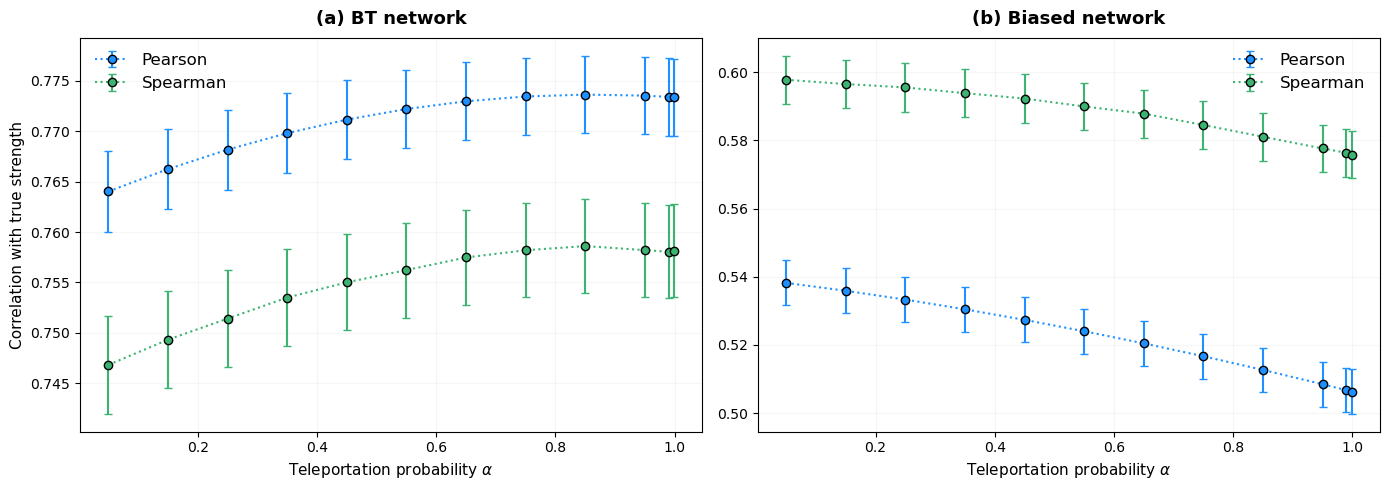

In [25]:
#plot of the results, BT netowrk
plt.figure(figsize=(14,5))


plt.subplot(1,2,1)
plt.errorbar(alphas, [BT_pagerank_correlations[alpha]["pearson"][0] for alpha in map(float, alphas)], 
             yerr=[BT_pagerank_correlations[alpha]["pearson"][1] for alpha in map(float, alphas)], 
             label="Pearson", marker="o", linestyle=":", capsize=3, markeredgecolor="black", color="dodgerblue")
plt.errorbar(alphas, [BT_pagerank_correlations[alpha]["spearman"][0] for alpha in map(float, alphas)], 
             yerr=[BT_pagerank_correlations[alpha]["spearman"][1] for alpha in map(float, alphas)], 
             label="Spearman", marker="o", linestyle=":", capsize=3, markeredgecolor="black", color="mediumseagreen")
plt.title("(a) BT network", fontsize=13, weight="bold", pad=10)
plt.xlabel(r"Teleportation probability $\alpha$", fontsize=11)
plt.ylabel("Correlation with true strength", fontsize=11)
plt.grid(True, alpha=0.1)
plt.legend(frameon=False, fontsize=12)

#plot of the results, biased network

plt.subplot(1,2,2)
plt.errorbar(alphas, [biased_pagerank_correlations[alpha]["pearson"][0] for alpha in map(float, alphas)], 
             yerr=[biased_pagerank_correlations[alpha]["pearson"][1] for alpha in map(float, alphas)], 
             label="Pearson", marker="o", linestyle=":", capsize=3, markeredgecolor="black", color="dodgerblue")
plt.errorbar(alphas, [biased_pagerank_correlations[alpha]["spearman"][0] for alpha in map(float, alphas)], 
             yerr=[biased_pagerank_correlations[alpha]["spearman"][1] for alpha in map(float, alphas)], 
             label="Spearman", marker="o", linestyle=":", capsize=3, markeredgecolor="black", color="mediumseagreen")
plt.title("(b) Biased network", fontsize=13, weight="bold", pad=10)
plt.xlabel(r"Teleportation probability $\alpha$", fontsize=11)
plt.grid(True, alpha=0.1)
plt.legend(frameon=False, fontsize=12)


plt.tight_layout()
plt.show()

## 5. Effect of Network Properties on Metric Correlations

Here, the study of influence of the nodes $N$ and edges $E$ number on all the correlations is studied. To do that, the density of the network is introduced:

\begin{equation*} d=\frac{E}{N(N-1)} \end{equation*}

This is a parameter of the following function, from which the number of edges can be found, as a function of the input $N$.

In [26]:
def compute_correlations(list_N, densities, alphas, network_type, graph_number=100):
    """
    Calculates correlations (Pearson and Spearman) between true strength
    and metrics (in-degree, Zermelo, PageRank) for different sizes N and densities.
    
    Args:
        N_list (list): graph sizes.
        densities (list: densities to test (between 0 and 1).
        alphas (list): values for PageRank.
        graph_number (int): number of graphs generated for each configuration.
        network_type (str): network type ('BT' or 'biased')
    
    Returns:
        dict: dictionary with densities and all correlations
    """

    results={}

    #going through all given N
    for N in list_N:
        print(f"\n-----Computing results for N={N}-----")

        #for stocking the results
        real_densities=[]
        in_degree_means, in_degree_errors = [], []
        zermelo_means, zermelo_errors = [], []
        pagerank_means, pagerank_errors = {alpha: [] for alpha in alphas}, {alpha: [] for alpha in alphas}

        for density in densities:
            print(f"Density: {density:.1f}")
            
            #calculating the goode E for having such a density
            E = int(density*N*(N-1))

            result=compare_metrics_with_true_strengths(N,E, network_type=network_type, graph_number=graph_number, alphas=alphas, return_real_E=True)

            #density
            real_densities.append(result["density_real_mean"])

            #in-degree
            in_degree_means.append(result["in_degree"]["spearman"][0])
            in_degree_errors.append(result["in_degree"]["spearman"][1])

            #zermelo computed strength
            zermelo_means.append(result["zermelo"]["spearman"][0])
            zermelo_errors.append(result["zermelo"]["spearman"][1])

            #PR
            for alpha in alphas:
                pagerank_means[alpha].append(result["pagerank"][alpha]["spearman"][0])
                pagerank_errors[alpha].append(result["pagerank"][alpha]["spearman"][1])

        
        results[N]={
            "densities": real_densities,
            "in_degree": {"mean": in_degree_means, "error": in_degree_errors},
            "zermelo": {"mean": zermelo_means, "error": zermelo_errors},
            "pagerank": {alpha: {"mean": pagerank_means[alpha], "error": pagerank_errors[alpha]} for alpha in alphas}
        }

    return results

In [27]:
list_N=[25,50,75,100]
densities=np.arange(0.1,1.1,0.1)
alphas = np.concatenate((np.arange(0.05, 1, 0.1), [0.99, 0.999]))

In [28]:
all_results = {}

for network_type in ["BT", "biased"]:
    file_name = f"{network_type}_correlations.pkl"

    if os.path.exists(file_name):
        print(f"Loading existing results for {network_type}...")
        with open(file_name, "rb") as f:
            all_results[network_type] = pickle.load(f)
    else:
        print(f"Computing correlations for {network_type} (this may take too much time!)...")
        all_results[network_type] = compute_correlations(list_N, densities, alphas, network_type=network_type)

        with open(file_name, "wb") as f:
            pickle.dump(all_results[network_type], f)

        print(f"Results saved in {file_name} networks")

Loading existing results for BT...
Loading existing results for biased...


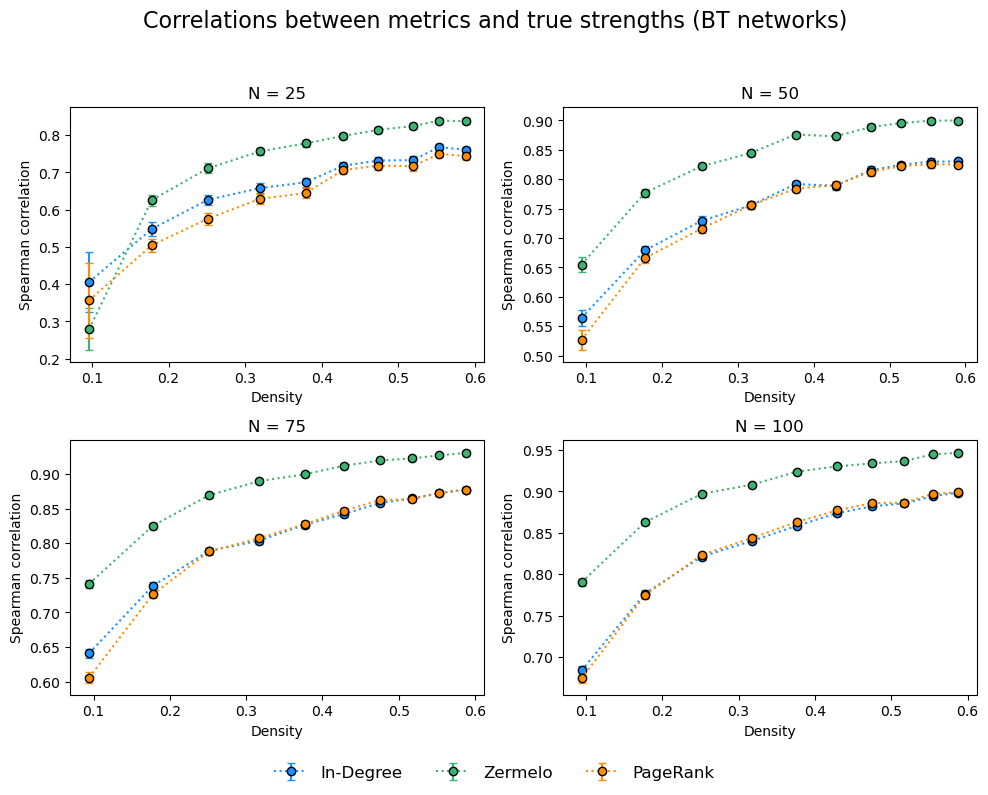

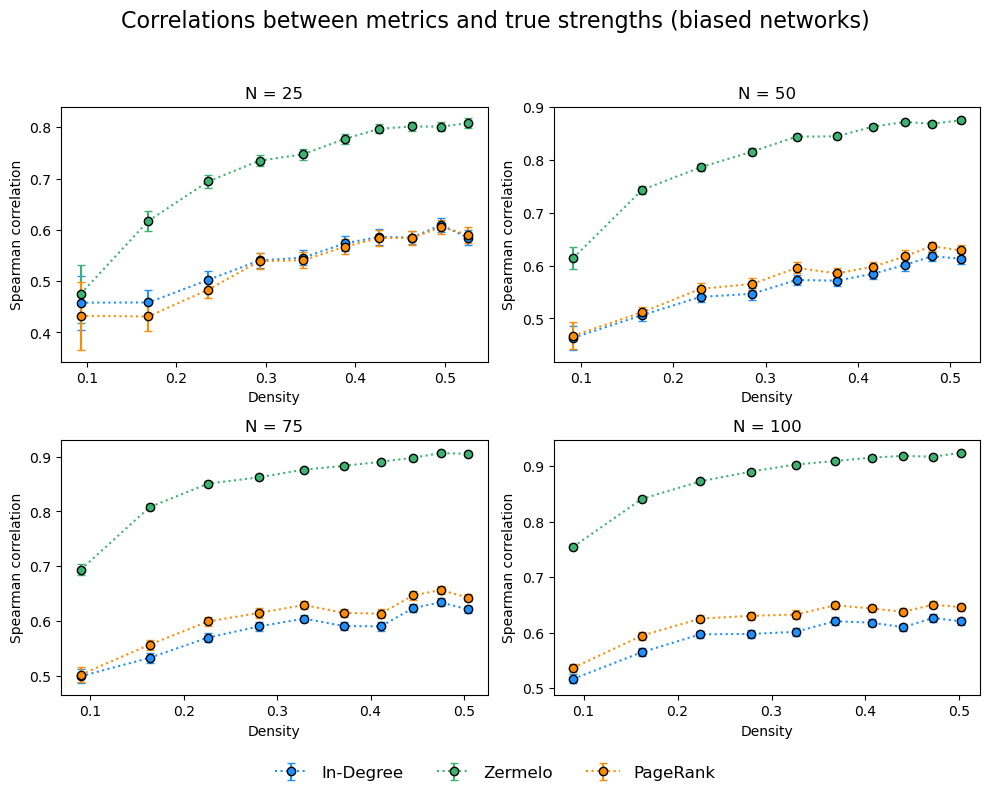

In [ ]:
for type in ["BT", "biased"]:
    plt.figure(figsize=(10,8))
    alpha = alphas[2] # typical value for alpha: 0.15

    for i, N in enumerate(list_N):
        plt.subplot(2,2,i+1)
        
        plt.errorbar(all_results[type][N]["densities"], all_results[type][N]["in_degree"]["mean"], 
                     yerr=all_results[type][N]["in_degree"]["error"], 
                     label="In-degree", marker="o", linestyle=":", capsize=3, markeredgecolor="black", color="dodgerblue", markersize=6)
        plt.errorbar(all_results[type][N]["densities"], all_results[type][N]["zermelo"]["mean"], 
                     yerr=all_results[type][N]["zermelo"]["error"], 
                     label="Zermelo", marker="o", linestyle=":", capsize=3, markeredgecolor="black", color="mediumseagreen", markersize=6)
        plt.errorbar(all_results[type][N]["densities"], all_results[type][N]["pagerank"][alphas[2]]["mean"], 
                     yerr=all_results[type][N]["pagerank"][alphas[2]]["error"], 
                     label="PageRank", marker="o", linestyle=":", capsize=3, markeredgecolor="black", color="darkorange", markersize=6)

        plt.title(f"N = {N}")
        plt.xlabel("Density")
        plt.ylabel("Spearman correlation")   


    plt.figlegend(["In-Degree", "Zermelo", "PageRank"], loc="lower center", ncol=3, fontsize=12, frameon=False)

    plt.suptitle(f"Correlations between metrics and true strengths ({type} networks)", fontsize=16)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

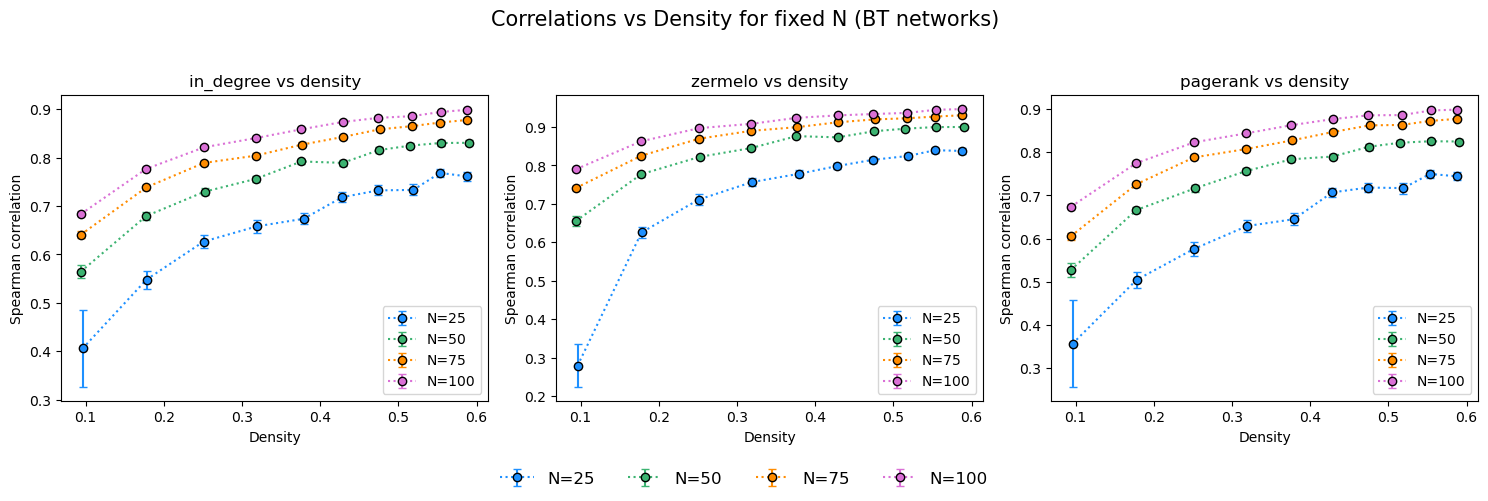

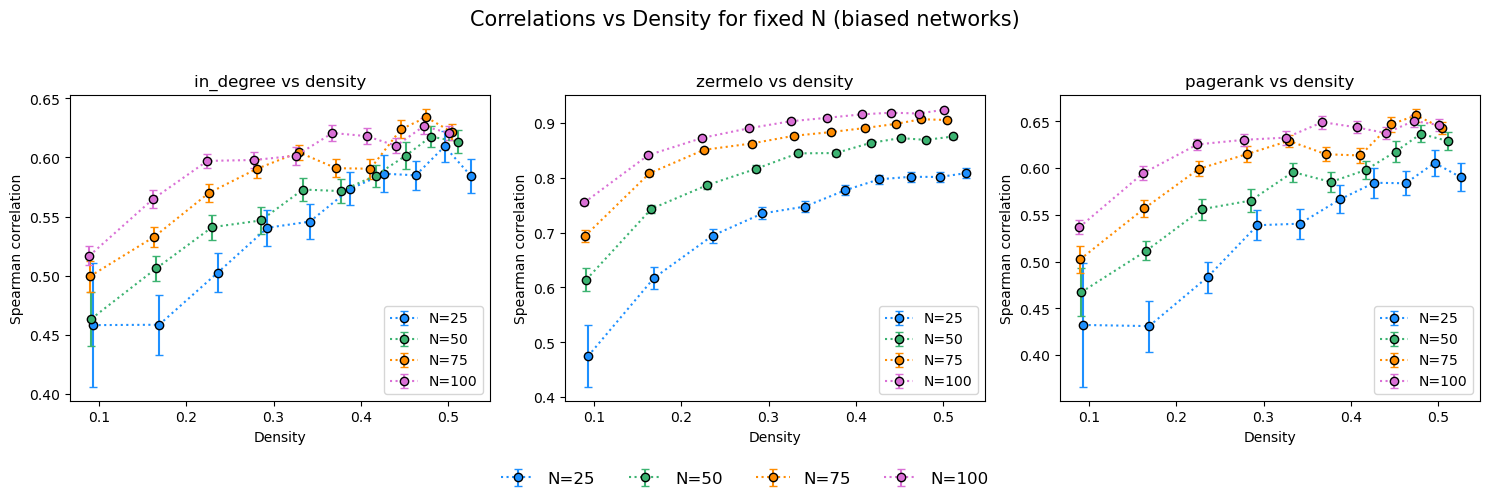

In [46]:
metrics = ["in_degree", "zermelo", "pagerank"]
alpha = alphas[2]
colors = ["dodgerblue", "mediumseagreen", "darkorange", "orchid"]

for network_type in ["BT", "biased"]:
    plt.figure(figsize=(15, 5))

    for j,metric in enumerate(metrics):
        plt.subplot(1,3,j+1)

        for i, N in enumerate(list_N):
            data_N=all_results[network_type][N]

            if metric == "pagerank":
                means = data_N["pagerank"][alpha]["mean"]
                errors = data_N["pagerank"][alpha]["error"]

            else:
                means = data_N[metric]["mean"]
                errors = data_N[metric]["error"]

            plt.errorbar(data_N["densities"], means, yerr=errors, 
                         label=f"N={N}", marker="o", linestyle=":", capsize=3, color=colors[i], markersize=6, markeredgecolor="black")
        
        plt.xlabel("Density")
        plt.ylabel("Spearman correlation")
        plt.title(f"{metric} vs density")
        plt.legend()

    plt.figlegend(["N=25", "N=50", "N=75", "N=100"], loc="lower center", ncol=len(list_N), fontsize=12, frameon=False)
    plt.suptitle(f"Correlations vs Density for fixed N ({network_type} networks)", fontsize=15)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

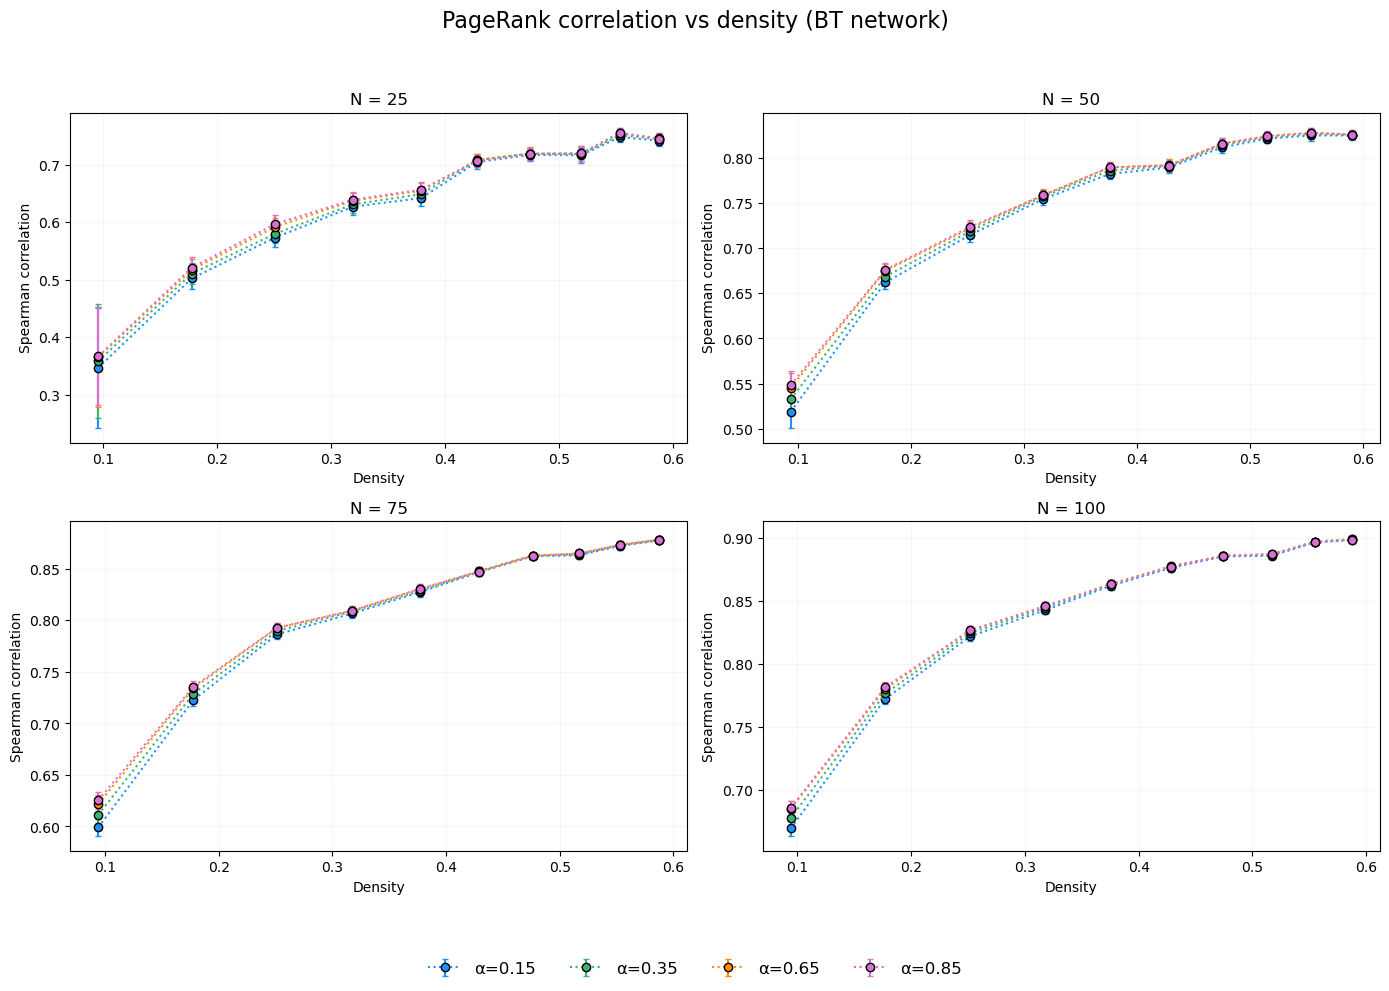

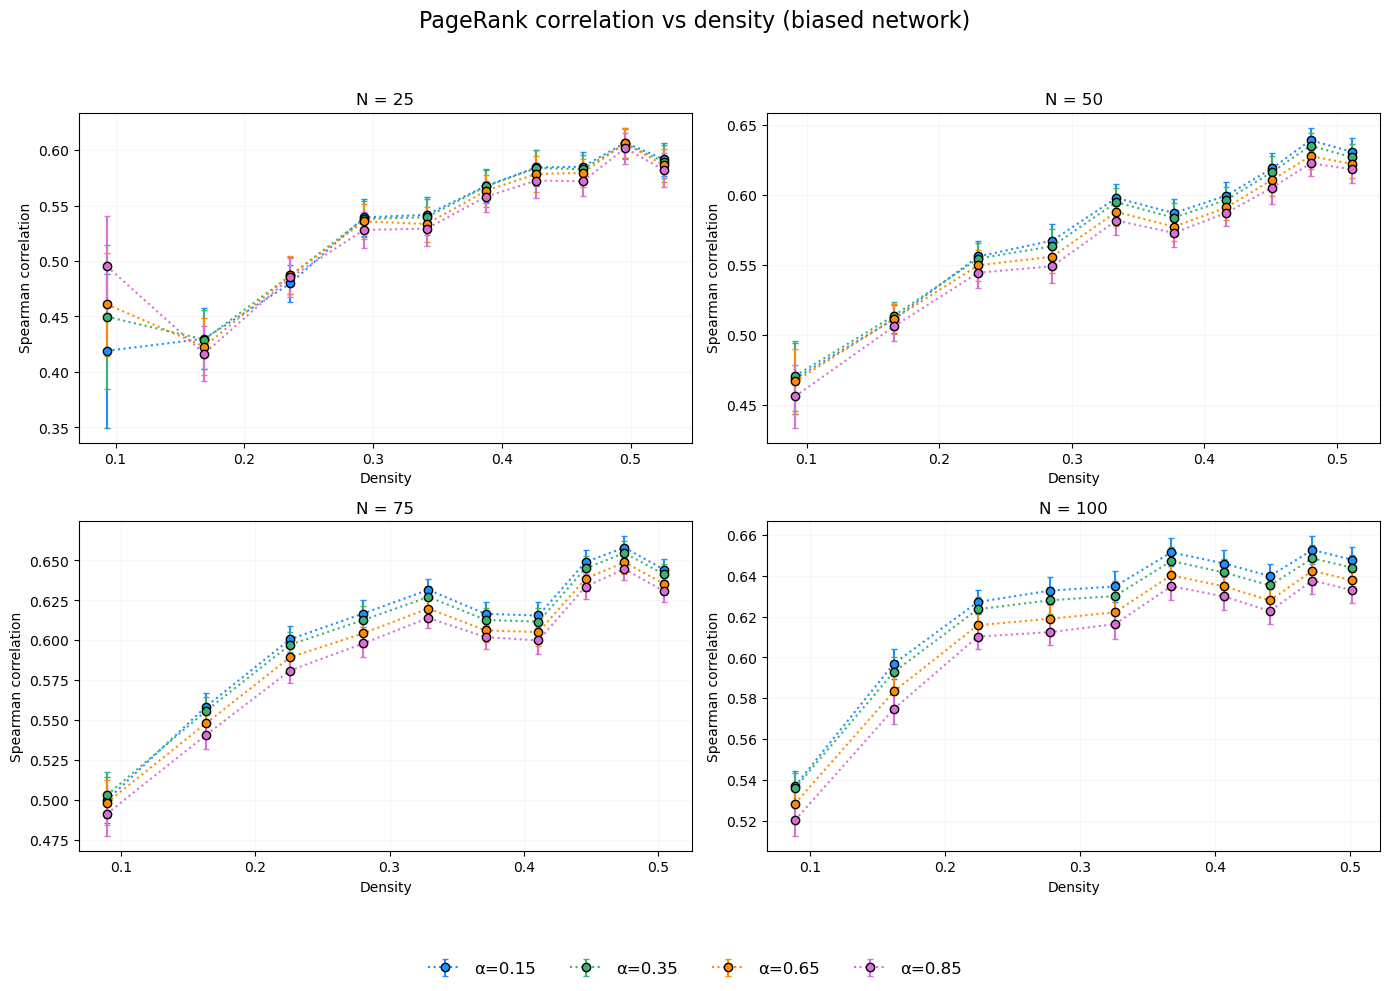

In [85]:
alpha_indices = [1,3,6,8]
s_alphas = alphas[alpha_indices]
colors = ["dodgerblue", "mediumseagreen", "darkorange", "orchid"]

for type in ["BT", "biased"]:
    plt.figure(figsize=(14, 10))

    for i, N in enumerate(list_N):

        plt.subplot(2, 2, i+1)
        data_N = all_results[type][N]

        for j, alpha in enumerate(s_alphas):
            means = data_N["pagerank"][alpha]["mean"]
            errors = data_N["pagerank"][alpha]["error"]
            plt.errorbar(data_N["densities"], means, yerr=errors, 
                         marker="o", markersize=6, linestyle=":", capsize=2, label=f"α={alpha:.2f}", 
                         color=colors[j], markeredgecolor="black")


        plt.xlabel("Density")
        plt.ylabel("Spearman correlation")
        plt.title(f"N = {N}")
        plt.grid(alpha=0.1)
    
    plt.suptitle(f"PageRank correlation vs density ({type} network)", fontsize=16)
    plt.figlegend([f"α={alphas[alpha_indices[0]]:.2f}", f"α={alphas[alpha_indices[1]]:.2f}", f"α={alphas[alpha_indices[2]]:.2f}", f"α={alphas[alpha_indices[3]]:.2f}"], loc="lower center", ncol=4, fontsize=12, frameon=False)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()   
        

## References

- **NetworkX documentation**,  
https://networkx.org/documentation/stable/tutorial.html, for understanding the basics of the library $\texttt{NetworkX}$ (26.09.2025)

- **PageRank algorithm**,  
https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html (29.09.2025)

- **Spearman and Pearson correlation**,  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html,  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html (30.09.2025)

- **KDE plot**,  
https://seaborn.pydata.org/generated/seaborn.kdeplot.html,  
https://www.geeksforgeeks.org/data-science/seaborn-kdeplot-a-comprehensive-guide (05.10.2025)
